# Overfitting, and the split that hides it

### A worked example on ocean dynamical regimes

Most overfitting tutorials show you a model that memorises its training set, then
fix it with dropout and call it a day. Gridded ocean data breaks that story in a
way worth understanding, because **neighbouring grid cells are not independent
samples**. Split them at random and your held-out set is not held out in any
meaningful sense.

This notebook works through three things, in order:

1. **The textbook picture.** A model with too much capacity and too few labels.
   The validation loss turns upward while the validation *accuracy* barely
   moves &mdash; so accuracy alone will not tell you when to stop.
2. **The split decides what you see.** The same model and the same data give a
   generalisation gap of `+0.001` or `+0.078` depending only on *how* the test
   pixels were chosen. We measure why.
3. **What actually helps.** Early stopping against a spatially separate region
   does the real work. Dropout and weight decay add little, and the gap that
   remains is not overfitting at all.

### The problem

We borrow step 2 of **THOR** (Tracking global Heating with Ocean Regimes):
predict which *barotropic vorticity regime* an ocean grid cell belongs to, from
local physical properties. Six classes, from a clustering of the vorticity
budget terms; the inputs are things a climate model can readily provide.

> Sonnewald, M. and Lguensat, R. (2021). *Revealing the impact of global heating
> on North Atlantic circulation using transparent machine learning.*
> Journal of Advances in Modeling Earth Systems **13**, e2021MS002496.
> [doi:10.1029/2021MS002496](https://doi.org/10.1029/2021MS002496) &middot;
> code: [maikejulie/DNN4Cli](https://github.com/maikejulie/DNN4Cli) (MIT)

The regime labels themselves come from the unsupervised step that precedes this
one (Sonnewald et al. 2019), which is why step 2 is a *supervised* problem: the
labels already exist, and we are learning to reproduce them from variables that
are available in models where the vorticity budget is not.

**Inputs.** We use THOR's full set of eight: wind stress curl, the 20-year mean
sea-surface height and its two gradients, bathymetry and its two gradients, and
the Coriolis parameter. All four source fields ship with this directory as a
1.8 MB `.npz`, so there is nothing to download. `make_dataset.py` shows exactly
how that file was built from the DNN4Cli arrays and 580 MB of yearly ECCO
sea-surface height files.

## 1. Setup

Everything here runs on CPU in a few minutes, offline.

In [1]:
from pathlib import Path

DATA = Path("data/thor_step2_fields.npz")
assert DATA.exists(), f"{DATA} is missing - run: python make_dataset.py"
print(f"{DATA} ({DATA.stat().st_size / 1e6:.2f} MB)")

data/thor_step2_fields.npz (1.83 MB)


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import binary_dilation
from sklearn.preprocessing import StandardScaler

SEED = 0
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

# THOR's regime palette, kept so the maps below are recognisable from the paper
REGIME_CMAP = ListedColormap(
    ["royalblue", "cyan", "yellow", "orange", "magenta", "red"]
)
print("torch", torch.__version__)

torch 2.9.0


## 2. Building the fields

The three arrays are on a 0.5&deg; grid, 360 latitudes by 720 longitudes:

| array | what it is |
| --- | --- |
| `curl` | wind stress curl |
| `bathy` | bathymetry |
| `ssh` | 20-year (240-month) mean sea-surface height |
| `label` | the six regime labels, `-1` over land |

From bathymetry and SSH we derive their horizontal gradients, and from latitude
the Coriolis parameter *f*. Gradients need physical spacing, so we build the grid
metric exactly as THOR does: metres per degree times the grid step, with the
zonal spacing shrinking as cos(latitude) towards the poles.

THOR takes its latitude field from the ECCO files. We rebuild it instead, which
is safe: the ECCO field is `linspace(-89.75, 89.75, 360)` broadcast across
longitude, identical to the last bit (checked when the `.npz` was built, max
difference exactly 0).

In [3]:
R_EARTH_DEG = 1.111774765625000e+05   # metres per degree, the constant THOR uses
OMEGA       = 7.2921e-5               # Earth's rotation rate, rad/s
DX_DEG      = 0.5                     # grid step

fields = np.load(DATA)
curl  = fields["curl"].astype("float64")
bathy = fields["bathy"].astype("float64")
ssh   = fields["ssh"].astype("float64")
label = fields["label"].astype("float64")
label[label == -1] = np.nan           # land is not a regime

ny, nx = curl.shape
lat = np.linspace(-90 + DX_DEG / 2, 90 - DX_DEG / 2, ny)[:, None] * np.ones((1, nx))

dy = np.gradient(lat, axis=0) * R_EARTH_DEG                    # metres per cell, north-south
dx = np.abs(np.cos(np.deg2rad(lat))) * R_EARTH_DEG * DX_DEG    # metres per cell, east-west
grad = lambda a: (np.gradient(a, axis=1) / dx, np.gradient(a, axis=0) / dy)

# THOR derives the zonal spacing with np.roll(lat, shift=-1) instead of using
# DX_DEG. That wraps at the north pole, so in the single row at 89.75 deg N it
# gets -179.5 deg instead of 0.5 deg: a spacing 359x too large with the wrong
# sign. We use the grid step directly. It changes 720 of ~149,600 cells, all
# of them in that polar row.

dHdx, dHdy = grad(bathy)
f = 2 * OMEGA * np.sin(np.deg2rad(lat))

dSdx, dSdy = grad(ssh)
FEATURES = np.stack([curl, ssh, dSdx, dSdy, bathy, dHdx, dHdy, f])
NAMES = ["wind stress curl", "SSH", "dSSH/dx", "dSSH/dy",
         "bathymetry", "dH/dx", "dH/dy", "Coriolis f"]

# a cell is usable only where every input and the label are defined
VALID = ~np.isnan(np.prod(np.stack([*FEATURES, label]), axis=0))

print(f"{len(FEATURES)} inputs: {', '.join(NAMES)}")
print(f"grid {ny} x {nx},  usable ocean cells: {VALID.sum():,} of {VALID.size:,}")
counts = np.bincount(label[VALID].astype(int), minlength=6)
print("class balance (%):", np.round(100 * counts / counts.sum(), 1))

8 inputs: wind stress curl, SSH, dSSH/dx, dSSH/dy, bathymetry, dH/dx, dH/dy, Coriolis f
grid 360 x 720,  usable ocean cells: 149,587 of 259,200
class balance (%): [30.4 23.7 16.1  7.9  5.1 16.7]


A quick check that the grid is the right way up before we trust any of it: row 0
should be Antarctic (mostly land), and *f* should be negative in the south and
positive in the north.

In [4]:
print("land fraction by latitude band, south to north:")
for i in range(0, ny, 60):
    lo, hi = lat[i, 0], lat[min(i + 59, ny - 1), 0]
    print(f"  {lo:+6.1f}° to {hi:+6.1f}°   {1 - VALID[i:i+60].mean():.2f}")
print(f"\nCoriolis f: {f[0,0]:+.2e} at the south edge, {f[-1,0]:+.2e} at the north edge")

land fraction by latitude band, south to north:
   -89.8° to  -60.2°   0.65
   -59.8° to  -30.2°   0.08
   -29.8° to   -0.2°   0.32
    +0.2° to  +29.8°   0.40
   +30.2° to  +59.8°   0.61
   +60.2° to  +89.8°   0.48

Coriolis f: -1.46e-04 at the south edge, +1.46e-04 at the north edge


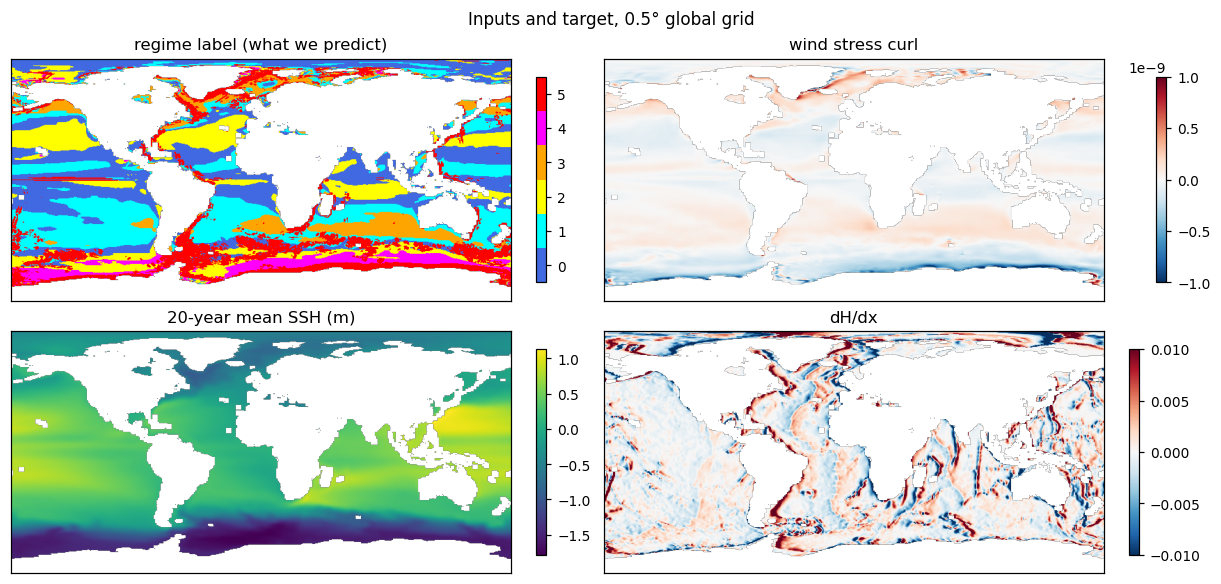

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.2), constrained_layout=True)
show = lambda ax, a, **kw: ax.imshow(np.flipud(a), aspect="auto", **kw)

im = show(axes[0, 0], np.where(VALID, label, np.nan), cmap=REGIME_CMAP, vmin=-0.5, vmax=5.5)
axes[0, 0].set_title("regime label (what we predict)")
fig.colorbar(im, ax=axes[0, 0], ticks=range(6), shrink=0.85)

im = show(axes[0, 1], np.where(VALID, curl, np.nan), cmap="RdBu_r", vmin=-1e-9, vmax=1e-9)
axes[0, 1].set_title("wind stress curl")
fig.colorbar(im, ax=axes[0, 1], shrink=0.85)

im = show(axes[1, 0], np.where(VALID, ssh, np.nan), cmap="viridis")
axes[1, 0].set_title("20-year mean SSH (m)")
fig.colorbar(im, ax=axes[1, 0], shrink=0.85)

im = show(axes[1, 1], np.where(VALID, dHdx, np.nan), cmap="RdBu_r", vmin=-1e-2, vmax=1e-2)
axes[1, 1].set_title("dH/dx")
fig.colorbar(im, ax=axes[1, 1], shrink=0.85)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Inputs and target, 0.5° global grid", fontsize=11)
plt.show()

Look at the regime map for a moment, because it is the whole reason this
notebook exists. The classes come in **large coherent patches**, not scattered
pixels. If you sample a test set uniformly at random from that map, almost every
test cell will sit inside a patch that also contains training cells. We will
measure exactly how often shortly.

## 3. The model

A small multilayer perceptron on standardised inputs, which is what THOR uses:
four hidden layers with `tanh`, softmax over six classes. The training loop
records loss and accuracy on both sets after every epoch, since the whole
notebook is about the difference between those two curves.

Note that the scaler is fitted on the **training split only**. Fitting it on
everything would leak the test set's mean and variance into training &mdash; a
smaller sin than the one we are chasing, but the same kind.

In [6]:
class MLP(nn.Module):
    def __init__(self, n_in=8, hidden=(24, 24, 16, 16), n_out=6, dropout=0.0):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.Tanh()]
            if dropout:
                layers += [nn.Dropout(dropout)]
            d = h
        self.net = nn.Sequential(*layers, nn.Linear(d, n_out))

    def forward(self, x):
        return self.net(x)


def train(Xtr, ytr, Xte, yte, hidden=(24, 24, 16, 16), dropout=0.0,
          weight_decay=0.0, epochs=120, lr=1e-3, batch=128, seed=SEED):
    'Train, recording train/held-out loss and accuracy each epoch.'
    torch.manual_seed(seed)
    model = MLP(Xtr.shape[1], hidden, dropout=dropout)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    lossf = nn.CrossEntropyLoss()

    Xtr, ytr = torch.as_tensor(Xtr), torch.as_tensor(ytr)
    Xte, yte = torch.as_tensor(Xte), torch.as_tensor(yte)
    hist = {k: [] for k in ("tr_loss", "te_loss", "tr_acc", "te_acc")}

    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), batch):
            idx = perm[i:i + batch]
            opt.zero_grad()
            lossf(model(Xtr[idx]), ytr[idx]).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            for tag, X, y in (("tr", Xtr, ytr), ("te", Xte, yte)):
                out = model(X)
                hist[f"{tag}_loss"].append(lossf(out, y).item())
                hist[f"{tag}_acc"].append((out.argmax(1) == y).float().mean().item())
    return model, hist


def pull(mask, n=None):
    'Feature matrix and labels for the cells in mask, optionally subsampled.'
    X = np.stack([a[mask] for a in FEATURES], axis=1).astype("float32")
    y = label[mask].astype("int64")
    if n is not None:
        keep = rng.choice(len(X), n, replace=False)
        X, y = X[keep], y[keep]
    return X, y

## 4. Act 1 &mdash; the textbook picture

Labelled ocean data is usually scarce, so let us act like it: **3000 labelled
cells**, about 2% of the map. We hold out the Atlantic as the test region, which
is what THOR does, and train two models that differ only in size.

In [7]:
def band(a, b):
    m = np.zeros_like(VALID)
    m[:, a:b] = True
    return VALID & m

ATLANTIC = band(200, 400)          # roughly 80°W to 20°E
N_TRAIN  = 3000

train_pool = VALID & ~ATLANTIC
Xtr, ytr = pull(train_pool, n=N_TRAIN)
Xte, yte = pull(ATLANTIC)

scaler = StandardScaler().fit(Xtr)                      # training split only
S = lambda X: scaler.transform(X).astype("float32")

print(f"train {len(Xtr):,} cells (subsampled)   test {len(Xte):,} cells (Atlantic)")
print(f"majority-class accuracy on the test region: "
      f"{np.bincount(yte).max() / len(yte):.3f}")

train 3,000 cells (subsampled)   test 40,328 cells (Atlantic)
majority-class accuracy on the test region: 0.254


In [8]:
runs = {}
for tag, hidden in [("THOR-sized  (24,24,16,16)", (24, 24, 16, 16)),
                    ("oversized   (256x4)",       (256,) * 4)]:
    _, runs[tag] = train(S(Xtr), ytr, S(Xte), yte, hidden=hidden, epochs=120)
    h = runs[tag]
    k = int(np.argmin(h["te_loss"]))
    print(f"{tag:28s} best test loss {h['te_loss'][k]:.3f} at epoch {k:>3d}, "
          f"{h['te_loss'][-1]:.3f} at epoch 120  ({h['te_loss'][-1] - h['te_loss'][k]:+.3f})")

THOR-sized  (24,24,16,16)    best test loss 0.525 at epoch  70, 0.574 at epoch 120  (+0.049)


oversized   (256x4)          best test loss 0.493 at epoch  11, 1.234 at epoch 120  (+0.741)


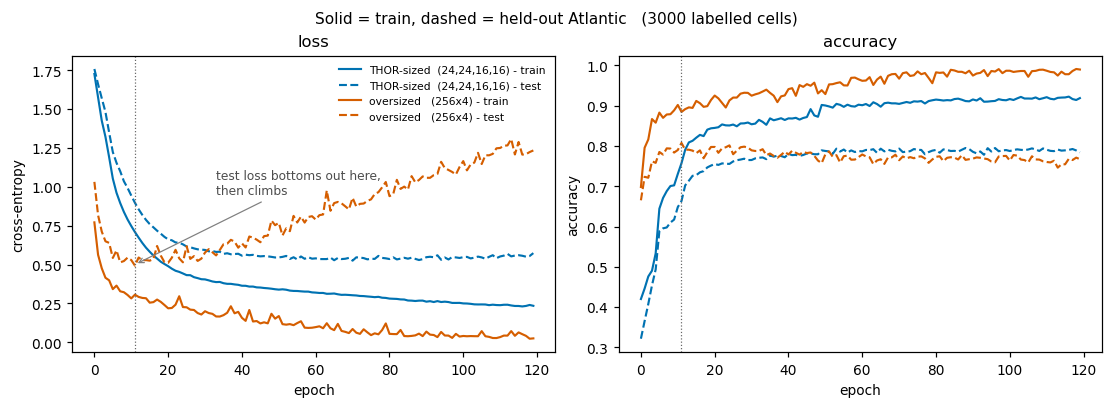

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
colours = {"THOR-sized  (24,24,16,16)": "#0072B2", "oversized   (256x4)": "#D55E00"}

for tag, h in runs.items():
    c = colours[tag]
    axes[0].plot(h["tr_loss"], color=c, lw=1.4, label=f"{tag} - train")
    axes[0].plot(h["te_loss"], color=c, lw=1.4, ls="--", label=f"{tag} - test")
    axes[1].plot(h["tr_acc"], color=c, lw=1.4)
    axes[1].plot(h["te_acc"], color=c, lw=1.4, ls="--")

k = int(np.argmin(runs["oversized   (256x4)"]["te_loss"]))
for ax in axes:
    ax.axvline(k, color="0.4", lw=0.8, ls=":")
    ax.set_xlabel("epoch")
axes[0].annotate("test loss bottoms out here,\nthen climbs", xy=(k, 0.5),
                 xytext=(k + 22, 0.95), fontsize=8, color="0.3",
                 arrowprops=dict(arrowstyle="->", color="0.5", lw=0.8))
axes[0].set_ylabel("cross-entropy"); axes[0].set_title("loss")
axes[1].set_ylabel("accuracy");      axes[1].set_title("accuracy")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Solid = train, dashed = held-out Atlantic   (3000 labelled cells)", fontsize=10)
plt.show()

The oversized model does exactly what the textbook promises: its training loss
keeps falling while its test loss bottoms out early and then climbs steadily.

**But look at the right-hand panel.** Test *accuracy* is nearly flat over the
same stretch. The model is not getting much worse at picking the right class; it
is getting worse at knowing how sure it should be. It grows confidently wrong,
and cross-entropy punishes that while accuracy shrugs.

This is the first practical lesson, and it costs nothing to apply: **watch a
proper scoring rule, not just accuracy.** A model selected on accuracy alone
would have happily trained for all 120 epochs and handed you badly calibrated
probabilities &mdash; which matters as soon as you want to do anything with the
class probabilities other than take their argmax.

The smaller, THOR-sized model shows no such rise. It has too few parameters to
memorise 3000 points.

## 5. Act 2 &mdash; the split decides what you see

Now the part that is specific to gridded geophysical data. We keep the model
fixed and change only **how the test cells are chosen**:

- **random** &mdash; sample test cells uniformly from the whole ocean;
- **geographic** &mdash; hold out the Atlantic, as above.

and we do it twice, once with 3000 training cells and once with all of them.

In [10]:
def random_split(n_train=None, frac_test=0.27):
    idx = np.flatnonzero(VALID.ravel()).copy()
    rng.shuffle(idx)
    cut = int(len(idx) * frac_test)
    te_idx, tr_idx = idx[:cut], idx[cut:]
    if n_train:
        tr_idx = tr_idx[:n_train]
    out = []
    for sel in (tr_idx, te_idx):
        m = np.zeros(VALID.size, bool); m[sel] = True
        out.append(m.reshape(VALID.shape))
    return out


def geographic_split(n_train=None):
    m_tr, m_te = VALID & ~ATLANTIC, VALID & ATLANTIC
    if n_train:
        idx = np.flatnonzero(m_tr.ravel()).copy()
        rng.shuffle(idx)
        m = np.zeros(VALID.size, bool); m[idx[:n_train]] = True
        m_tr = m.reshape(VALID.shape)
    return m_tr, m_te


def touching_fraction(m_tr, m_te):
    'Share of test cells with a training cell in their 8-neighbourhood.'
    neighbourhood = binary_dilation(m_tr, np.ones((3, 3), bool))
    return (neighbourhood & m_te).sum() / m_te.sum()

In [11]:
rows = []
for n_train, size_label in [(N_TRAIN, f"{N_TRAIN:,} cells"), (None, "all cells")]:
    for scheme, splitter in [("random", random_split), ("geographic", geographic_split)]:
        m_tr, m_te = splitter(n_train)
        Xa, ya = pull(m_tr)
        Xb, yb = pull(m_te)
        sc = StandardScaler().fit(Xa)
        _, h = train(sc.transform(Xa).astype("float32"), ya,
                     sc.transform(Xb).astype("float32"), yb,
                     hidden=(24, 24, 16, 16), epochs=80)
        rows.append(dict(size=size_label, scheme=scheme, n=m_tr.sum(),
                         tr=h["tr_acc"][-1], te=h["te_acc"][-1],
                         gap=h["tr_acc"][-1] - h["te_acc"][-1],
                         touch=touching_fraction(m_tr, m_te)))

hdr = f"{'training set':>14} {'split':>12} {'train':>8} {'held-out':>10} {'gap':>8} {'test cells adjacent':>21}"
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['size']:>14} {r['scheme']:>12} {r['tr']:>8.3f} {r['te']:>10.3f} "
          f"{r['gap']:>+8.3f} {100 * r['touch']:>20.1f}%")

  training set        split    train   held-out      gap   test cells adjacent
------------------------------------------------------------------------------
   3,000 cells       random    0.906      0.877   +0.029                 14.5%
   3,000 cells   geographic    0.921      0.786   +0.135                  0.1%
     all cells       random    0.911      0.911   -0.000                 99.9%
     all cells   geographic    0.925      0.821   +0.105                  0.7%


Read the last column first, because it explains the rest.

With a random split over the full dataset, **99.9% of the cells in the test set
are directly adjacent to a cell the model trained on.** The model is not
generalising to new places at all; it is interpolating between points it has
already seen, at a grid spacing where neighbouring cells are nearly the same
water. The reported gap is essentially zero &mdash; in this run very slightly
negative, the held-out score landing a hair *above* the training score. That
is a perfectly fair measurement of interpolation skill, and interpolation is
not the question anyone is asking.

Hold out the Atlantic instead and the adjacency drops to under 1% (only the
cells along the basin's edge), and the gap jumps by an order of magnitude or
more. That number is the one that answers the question you actually care about:
*will this model work somewhere I have no labels?*

Notice too that shrinking the training set to 3000 cells narrows the gap between
the two schemes but does not close it. Sparse sampling reduces adjacency to
about 15%, yet the random split still understates the gap several-fold. Spatial
correlation reaches well beyond the neighbouring cell.

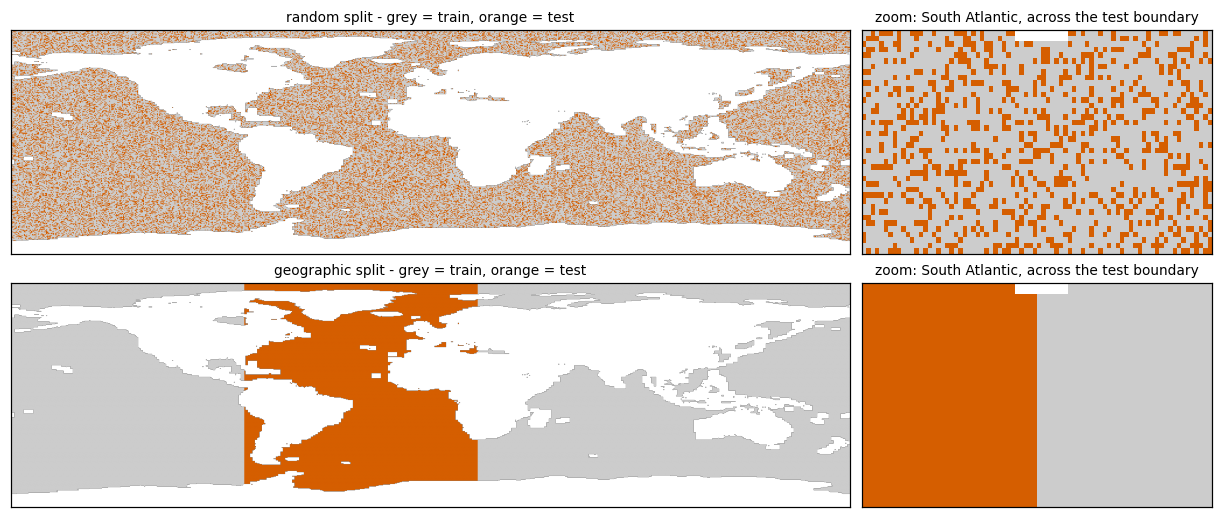

In [12]:
m_tr_r, m_te_r = random_split(n_train=None)
m_tr_g, m_te_g = geographic_split(n_train=None)

fig, axes = plt.subplots(2, 2, figsize=(11, 4.6), constrained_layout=True,
                         gridspec_kw={"width_ratios": [2.4, 1]})
ZOOM = (slice(70, 110), slice(360, 440))   # South Atlantic, straddling 20 deg E

for row, (m_tr, m_te, name) in enumerate([
        (m_tr_r, m_te_r, "random split"),
        (m_tr_g, m_te_g, "geographic split")]):
    canvas = np.full(VALID.shape, np.nan)
    canvas[m_tr] = 0
    canvas[m_te] = 1
    cmap = ListedColormap(["#cccccc", "#D55E00"])
    axes[row, 0].imshow(np.flipud(canvas), cmap=cmap, aspect="auto", vmin=-0.5, vmax=1.5)
    axes[row, 0].set_title(f"{name} - grey = train, orange = test", fontsize=9)
    axes[row, 1].imshow(np.flipud(canvas[ZOOM]), cmap=cmap, aspect="auto", vmin=-0.5, vmax=1.5,
                        interpolation="nearest")
    axes[row, 1].set_title("zoom: South Atlantic, across the test boundary", fontsize=9)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
plt.show()

The zoom, a window over the South Atlantic that crosses the test region's
eastern edge at 20&deg;E, makes the mechanism obvious. Under the random split
every orange test cell is ringed by grey training cells. Under the geographic
split the same window is split cleanly in two, and the model has to
extrapolate across that line.

## 6. Act 3 &mdash; what actually helps

Act 1 suggests regularisation; Act 2 says measure honestly. Combining them
raises an awkward question: in Act 1 we early-stopped on the *Atlantic*, then
reported the Atlantic score. That is leakage of a subtler kind &mdash; the stopping
epoch was chosen using the very region we then scored.

So we use three geographically separate regions:

| split | region | used for |
| --- | --- | --- |
| train | Indian + western Pacific | fitting weights |
| validation | eastern Pacific | choosing when to stop |
| test | Atlantic | scored once, at the end |

In [13]:
TRAIN_R = band(400, 720)     # 20°E to 180°E  - Indian + western Pacific
VAL_R   = band(0, 200)       # 180°W to 80°W  - eastern Pacific
TEST_R  = band(200, 400)     # 80°W to 20°E   - Atlantic

for nm, m in [("train", TRAIN_R), ("val", VAL_R), ("test", TEST_R)]:
    c = np.bincount(label[m].astype(int), minlength=6)
    print(f"{nm:5s} {m.sum():>7,} cells   class %: {np.round(100 * c / c.sum(), 1)}")

train  57,283 cells   class %: [29.6 20.9 13.5 11.9  6.2 18. ]
val    51,976 cells   class %: [35.3 29.3 18.2  3.   4.4  9.7]
test   40,328 cells   class %: [25.4 20.5 16.9  8.6  4.4 24.1]


In [14]:
Xtr3, ytr3 = pull(TRAIN_R, n=N_TRAIN)
Xva3, yva3 = pull(VAL_R)
Xte3, yte3 = pull(TEST_R)
sc3 = StandardScaler().fit(Xtr3)
T = lambda X: sc3.transform(X).astype("float32")

BIG = (256,) * 4
configs = [
    ("oversized, no regularisation", BIG, 0.0, 0.0),
    ("oversized + dropout 0.3",      BIG, 0.3, 0.0),
    ("oversized + weight decay 1e-3", BIG, 0.0, 1e-3),
    ("oversized + both",             BIG, 0.3, 1e-3),
    ("THOR-sized, no regularisation", (24, 24, 16, 16), 0.0, 0.0),
]

results = []
for tag, hidden, drop, wd in configs:
    # pass 1: find the stopping epoch using the Pacific validation band
    _, hv = train(T(Xtr3), ytr3, T(Xva3), yva3, hidden=hidden, dropout=drop,
                  weight_decay=wd, epochs=120)
    stop = int(np.argmin(hv["te_loss"])) + 1
    # pass 2: refit to that epoch, then score the Atlantic exactly once
    _, ht = train(T(Xtr3), ytr3, T(Xte3), yte3, hidden=hidden, dropout=drop,
                  weight_decay=wd, epochs=stop)
    results.append(dict(tag=tag, stop=stop, tr=ht["tr_acc"][-1],
                        te=ht["te_acc"][-1], gap=ht["tr_acc"][-1] - ht["te_acc"][-1]))
    print(f"{tag:30s} stop @ epoch {stop:>3d}   train {ht['tr_acc'][-1]:.3f}   "
          f"Atlantic {ht['te_acc'][-1]:.3f}   gap {results[-1]['gap']:+.3f}")

# for contrast: the same oversized model with no early stopping at all
_, hn = train(T(Xtr3), ytr3, T(Xte3), yte3, hidden=BIG, epochs=120)
print(f"\n{'oversized, trained to epoch 120':30s} {'':>16} train {hn['tr_acc'][-1]:.3f}   "
      f"Atlantic {hn['te_acc'][-1]:.3f}   gap {hn['tr_acc'][-1] - hn['te_acc'][-1]:+.3f}")
print(f"{'':30s} {'':>16} Atlantic cross-entropy "
      f"{min(hn['te_loss']):.3f} at best epoch -> {hn['te_loss'][-1]:.3f} at epoch 120")

oversized, no regularisation   stop @ epoch  19   train 0.907   Atlantic 0.816   gap +0.092


oversized + dropout 0.3        stop @ epoch  81   train 0.929   Atlantic 0.794   gap +0.136


oversized + weight decay 1e-3  stop @ epoch  47   train 0.914   Atlantic 0.799   gap +0.115


oversized + both               stop @ epoch 102   train 0.911   Atlantic 0.798   gap +0.114


THOR-sized, no regularisation  stop @ epoch 105   train 0.915   Atlantic 0.812   gap +0.103



oversized, trained to epoch 120                  train 0.980   Atlantic 0.769   gap +0.211
                                                Atlantic cross-entropy 0.503 at best epoch -> 1.246 at epoch 120


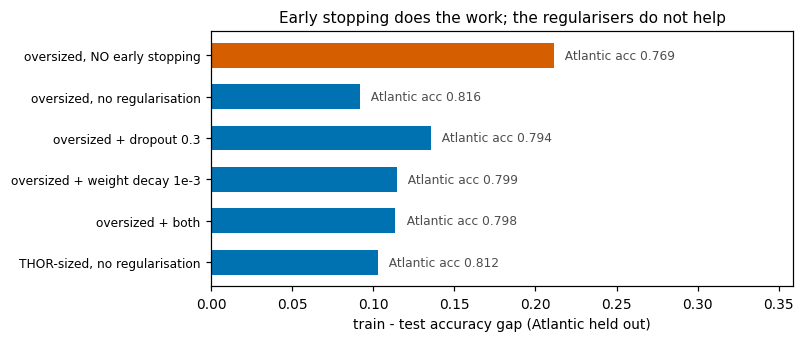

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.0), constrained_layout=True)
tags = [r["tag"] for r in results][::-1] + ["oversized, NO early stopping"]
gaps = [r["gap"] for r in results][::-1] + [hn["tr_acc"][-1] - hn["te_acc"][-1]]
accs = [r["te"] for r in results][::-1] + [hn["te_acc"][-1]]
cols = ["#0072B2"] * len(results) + ["#D55E00"]
y = np.arange(len(tags))
ax.barh(y, gaps, color=cols, height=0.6)
for i, (g, a) in enumerate(zip(gaps, accs)):
    ax.text(g + 0.002, i, f"  Atlantic acc {a:.3f}", va="center", fontsize=8, color="0.3")
ax.set_yticks(y); ax.set_yticklabels(tags, fontsize=8)
ax.set_xlabel("train - test accuracy gap (Atlantic held out)")
ax.set_xlim(0, max(gaps) * 1.7)
ax.set_title("Early stopping does the work; the regularisers do not help", fontsize=10)
plt.show()

This is not the tidy result a tutorial would script, and it is the most useful
thing in the notebook.

**Early stopping against a separate region does the real work.** Without it the
oversized model's Atlantic cross-entropy roughly doubles as it trains on.

**Dropout and weight decay then make it slightly worse.** Dropout costs 2.2
points of Atlantic accuracy against no regularisation at all, weight decay 1.7.
Both let training run much longer before the validation loss turns, and the
extra epochs buy fit to the Indo-Pacific that does not transfer. Shrinking to
the THOR-sized network does not help either.

The reason is that the remaining gap, roughly `+0.09` to `+0.14`, **is not
overfitting**.
The model is not memorising the Indian Ocean; it is being asked about an ocean
whose regime mix genuinely differs. Look back at the class balances printed
above: the validation and test regions differ substantially from the training
region in how common each regime is, and the Atlantic contains dynamical
situations that the Indo-Pacific training region simply does not cover. That is
**distribution shift**, and no amount of dropout fixes it. The honest responses
are to get labels from the region you care about, to use a model whose
extrapolation you can reason about, or to report the geographic gap openly as a
limit on where the model may be applied.

Knowing *which* of the two you are looking at is the point. A rising validation
loss means overfitting and early stopping will help. A stubborn gap that
survives every regulariser means your training region does not represent your
target region, and only different data will fix it.

## 7. Takeaways

1. **Accuracy is a poor overfitting detector.** Cross-entropy turned up sharply
   while accuracy stayed flat. Watch a proper scoring rule.
2. **Never split gridded ocean data at random.** With a random split, 99.9% of
   our test cells touched a training cell and the gap vanished completely,
   while holding out a basin exposed a gap of `+0.105`. Hold out regions,
   blocks or time periods &mdash; something with spatial extent.
3. **Early stopping needs its own region.** Tuning on the set you report is
   leakage. Train, validate and test on three separate areas.
4. **Distinguish overfitting from distribution shift.** They look alike in a
   single number and have completely different remedies.
5. **Fit preprocessing on the training split only.** The scaler above sees
   training cells and nothing else.

### Things worth trying from here

- Rotate which basin is held out and see how much the gap moves; the Atlantic is
  not special, and the spread across basins is itself a useful uncertainty.
- Replace the single held-out basin with **spatial block cross-validation**:
  tile the globe, hold out whole tiles in turn. Cheaper than losing a basin and
  it gives an error bar.
- Drop the three SSH-derived inputs and re-run. Adding them lifts the
  random-split score from 0.890 to 0.911 but leaves the Atlantic at 0.821,
  a touch *below* the five-input 0.825 &mdash; better features improved the number
  a random split reports and did nothing for the one that matters.
- Train the 50-member ensemble THOR actually uses and check whether ensembling
  narrows the geographic gap or merely stabilises it.

### References

- Sonnewald, M. and Lguensat, R. (2021). *Revealing the impact of global heating
  on North Atlantic circulation using transparent machine learning.* JAMES 13,
  e2021MS002496. [doi:10.1029/2021MS002496](https://doi.org/10.1029/2021MS002496)
- Sonnewald, M., Wunsch, C. and Heimbach, P. (2019). *Unsupervised learning
  reveals geography of global ocean dynamical regions.* Earth and Space Science
  6, 784-794. [doi:10.1029/2018EA000519](https://doi.org/10.1029/2018EA000519)
- Roberts, D. R. et al. (2017). *Cross-validation strategies for data with
  temporal, spatial, hierarchical, or phylogenetic structure.* Ecography 40,
  913-929. [doi:10.1111/ecog.02881](https://doi.org/10.1111/ecog.02881)

Input data from [maikejulie/DNN4Cli](https://github.com/maikejulie/DNN4Cli),
MIT licensed, downloaded rather than redistributed.